# **Cardiovascular Disease Prediction: A Machine Learning Approach**

### *Author: Sofia Natale*

#### *Clinical Background*

Cardiovascular diseases represent the leading cause of death worldwide, accounting for approximately 19.8 million deaths each year according to the World Health Organization (WHO). Early identification of individuals at risk is therefore essential for implementing preventive strategies and improving long-term patient outcomes.

In recent years, machine learning techniques have increasingly been applied in the medical domain to support diagnostic processes and clinical decision-making. By analyzing clinical data collected during routine examinations, predictive models can identify patterns associated with cardiovascular conditions and assist in the early detection of high-risk patients.

---

#### *Project Overview*

This project develops a complete machine learning pipeline for predicting the presence of cardiovascular disease using clinical patient data. The workflow includes several stages:

1. [Data Preprocessing](#data-preprocessing)
2. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
3. [Data Preparation](#data-preparation)
4. [Feature Engineering](#feature-engineering)
5. [Model Training](#model-training)
6. [Evaluation and Comparison](#evaluation-and-comparison)

The goal of the study is to analyze how different machine learning algorithms perform in distinguishing between healthy individuals and patients affected by heart disease. To achieve this objective, four widely used classification algorithms are implemented and compared:

- Logistic Regression  
- Gaussian Naive Bayes  
- Support Vector Machine (SVM)  
- Random Forest  

The performance of these models is evaluated in order to determine which approach provides the most reliable predictions for cardiovascular disease detection within the dataset.

---


### **Step 0: Import Required Libraries**

In this step, all the Python libraries necessary for building the machine learning pipeline are imported. These libraries support data manipulation, visualization, model development, and performance evaluation throughout the project.

*Core Data Manipulation*
- `pandas` and `numpy` for data handling and numerical computations  
- `os` and `datetime` for file management and timestamp handling  
- `pickle` and `joblib` for saving and loading trained models and other objects  

*Data Visualization*
- `matplotlib.pyplot` and `seaborn` for generating plots and visualizations  
- `scipy.stats` for statistical computations such as Z-score calculations  

*Machine Learning Pipeline*
- `train_test_split` for dividing the dataset into training and testing subsets  
- `StratifiedKFold` for stratified cross-validation  
- `GridSearchCV` for hyperparameter optimization  
- `MinMaxScaler` for feature normalization  
- `make_scorer` for creating custom scoring functions for GridSearchCV  

*Machine Learning Models*
- `LogisticRegression` for linear classification  
- `RandomForestClassifier` for ensemble-based tree classification  
- `SVC` (Support Vector Classifier) for kernel-based classification  
- `GaussianNB` for probabilistic classification based on Bayes' theorem  

*Evaluation Metrics*
- `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score` for performance evaluation  
- `confusion_matrix`, `classification_report`, `matthews_corrcoef` for detailed model assessment  
- `roc_curve` and `auc` for Receiver Operating Characteristic (ROC) analysis  

*Warning Management*
- `warnings.filterwarnings('ignore')` is used to suppress non-critical warnings and maintain cleaner output during execution.

These libraries collectively provide the tools required to implement a robust and reproducible machine learning workflow for cardiovascular disease prediction.


In [74]:
# Core data manipulation
import pickle
import joblib
from datetime import datetime
import os
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import make_scorer

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, matthews_corrcoef)
from sklearn.metrics import roc_curve, auc

# Warning suppression
import warnings
warnings.filterwarnings('ignore')

### **Step 1: Data Preprocessing**

**Dataset Description**  
> *SOURCE* - [UCI Machine Learning Repository (Heart Disease Dataset)](https://archive.ics.uci.edu/dataset/45/heart+disease)

The dataset combines patient records from four independent studies: Cleveland, Hungarian, Switzerland, and the VA Long Beach database.

- **Total Samples**: 920 patient records (original)
- **Features**: 13 clinical and diagnostic attributes
- **Target Classes**: 0 (absence) to 4 (presence with varying severity levels)

---

#### **1.1: Original Features and Data Cleaning**

The dataset contains **13 clinical features**, but it also includes missing values, which are marked with a "?" in the source files.

A crucial initial cleaning step is performed to handle this missing data:

- **Handling Missing Values**: All missing values are imputed (filled) using the **median** of their respective columns. The median is chosen over the mean because it is more robust to outliers and provides a more representative central value for skewed medical data. This ensures no data is lost and the dataset is ready for analysis.

The original features are as follows:

| Feature | Type | Description |
|---------|------|-------------|
| `age` | Numerical | Patient age in years |
| `sex` | Binary | 1 = male, 0 = female |
| `cp` | Categorical | Chest pain type (1-4) |
| `trestbps` | Numerical | Resting blood pressure (mm Hg) |
| `chol` | Numerical | Serum cholesterol (mg/dL) |
| `fbs` | Binary | Fasting blood sugar > 120 mg/dL (1 = true, 0 = false) |
| `restecg` | Categorical | Resting electrocardiographic results (0-2) |
| `thalach` | Numerical | Maximum heart rate achieved |
| `exang` | Binary | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | Numerical | ST depression induced by exercise relative to rest |
| `slope` | Categorical | Slope of the peak exercise ST segment (1-3) |
| `ca` | Numerical | Number of major vessels colored by fluoroscopy (0-3) |
| `thal` | Categorical | Thalassemia type (3, 6, 7) |

In [75]:
# Define column names based on the UCI documentation
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Use na_values='?' because missing data is marked with '?' in these files
cleveland = pd.read_csv('datasets/processed.cleveland.data', names=columns, na_values='?')
hungary = pd.read_csv('datasets/processed.hungarian.data', names=columns, na_values='?')
switzerland = pd.read_csv('datasets/processed.switzerland.data', names=columns, na_values='?')
va = pd.read_csv('datasets/processed.va.data', names=columns, na_values='?')

# Merge all data into one DataFrame
df = pd.concat([cleveland, hungary, switzerland, va], ignore_index=True)
print(f"Total records loaded: {len(df)}")

Total records loaded: 920


In [76]:
# Handle missing values by filling them with the median of each column
df = df.fillna(df.median())
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [77]:
# Save the combined and cleaned dataset to a new CSV file
df.to_csv('datasets/heart_disease_combined.csv', index=False)
print("File saved successfully as 'heart_disease_combined.csv'")

File saved successfully as 'heart_disease_combined.csv'


In [78]:
df = pd.read_csv('datasets/heart_disease_combined.csv')

#### **1.2: Categorical Features Encoding**

After the initial preprocessing and missing value imputation, the categorical variables are transformed from their original numeric codes into descriptive labels. This step is crucial for improving interpretability during Exploratory Data Analysis (EDA) and for understanding the clinical meaning of each category.

**Chest Pain Type (`cp`)**

This feature describes the type of chest pain experienced by the patient. The original numeric values (1-4) are mapped to clinically meaningful categories:

In [79]:
df['cp'][df['cp'] == 1] = 'typical angina'
df['cp'][df['cp'] == 2] = 'atypical angina'
df['cp'][df['cp'] == 3] = 'non-anginal pain'
df['cp'][df['cp'] == 4] = 'asymptomatic'
df['cp'].value_counts()

cp
asymptomatic        496
non-anginal pain    204
atypical angina     174
typical angina       46
Name: count, dtype: int64

| Original Code | Mapped Value | Description |
|---------------|--------------|-------------|
| 1 | typical angina | Classic chest pain with characteristic symptoms: substernal discomfort, precipitated by exertion or stress, relieved by rest or nitroglycerin |
| 2 | atypical angina | Chest pain that has some but not all characteristic features of typical angina |
| 3 | non-anginal pain | Chest pain that does not meet criteria for angina (e.g., sharp, localized, positional) |
| 4 | asymptomatic | No chest pain symptoms reported |

**Resting Electrocardiographic Results (`restecg`)**

This feature captures abnormalities in the resting electrocardiogram (ECG), which measures the electrical activity of the heart.

In [80]:
df['restecg'][df['restecg'] == 0] = 'normal'
df['restecg'][df['restecg'] == 1] = 'ST-T wave abnormality'
df['restecg'][df['restecg'] == 2] = 'left ventricular hypertrophy'
df['restecg'].value_counts()

restecg
normal                          553
left ventricular hypertrophy    188
ST-T wave abnormality           179
Name: count, dtype: int64

| Original Code | Mapped Value | Description |
|---------------|--------------|-------------|
| 0 | normal | Normal resting ECG with no significant abnormalities |
| 1 | ST-T wave abnormality | ST segment depression or T wave inversions (> 0.05 mV), indicating possible ischemia or electrolyte imbalances |
| 2 | left ventricular hypertrophy | Enlarged left ventricle, often due to chronic hypertension, showing increased QRS voltage |

**ST Segment Slope (`slope`)**

This feature describes the slope of the ST segment during peak exercise, which is an important indicator of cardiac stress response and prognosis. The ST segment is the portion of the ECG between the end of the QRS complex (J point) and the beginning of the T wave. It represents the period when the heart's ventricles are completely depolarized and begin ventricular repolarization.

In [81]:
df['slope'][df['slope'] == 1] = 'upsloping'
df['slope'][df['slope'] == 2] = 'flat'
df['slope'][df['slope'] == 3] = 'downsloping'
df['slope'].value_counts()

slope
flat           654
upsloping      203
downsloping     63
Name: count, dtype: int64

| Original Code | Mapped Value | Description | Prognostic Significance |
|---------------|--------------|-------------|------------------------|
| 1 | upsloping | ST segment rises progressively during exercise | Generally considered normal or low risk |
| 2 | flat | ST segment remains horizontal during exercise | Intermediate risk, may indicate ischemia |
| 3 | downsloping | ST segment descends during exercise | High risk, strongly associated with ischemia and worse prognosis |

**Sex Encoding**

The sex feature is also transformed for better readability in visualizations and analysis:

In [82]:
df["sex"] = df.sex.apply(lambda  x:'male' if x==1 else 'female')

| Original Code | Mapped Value | Clinical Relevance |
|---------------|--------------|-------------------|
| 0 | female | Women typically present with heart disease 7-10 years later than men and may have different symptom patterns |
| 1 | male | Men have higher baseline risk of coronary artery disease|

In [83]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,male,typical angina,145.0,233.0,1.0,left ventricular hypertrophy,150.0,0.0,2.3,downsloping,0.0,6.0,0
1,67.0,male,asymptomatic,160.0,286.0,0.0,left ventricular hypertrophy,108.0,1.0,1.5,flat,3.0,3.0,2
2,67.0,male,asymptomatic,120.0,229.0,0.0,left ventricular hypertrophy,129.0,1.0,2.6,flat,2.0,7.0,1
3,37.0,male,non-anginal pain,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,3.0,0
4,41.0,female,atypical angina,130.0,204.0,0.0,left ventricular hypertrophy,172.0,0.0,1.4,upsloping,0.0,3.0,0


---

### **Step 2: Exploratory Data Analysis (EDA)**

EDA is performed to understand the structure, quality and patterns in the dataset. This includes examining distributions and exploring relationships between features and the target variable.

#### **2.1: Target Variable Distribution Analysis**

This visualization provides a comprehensive view of how heart disease is distributed across the patient population, both as a binary condition and across severity levels.

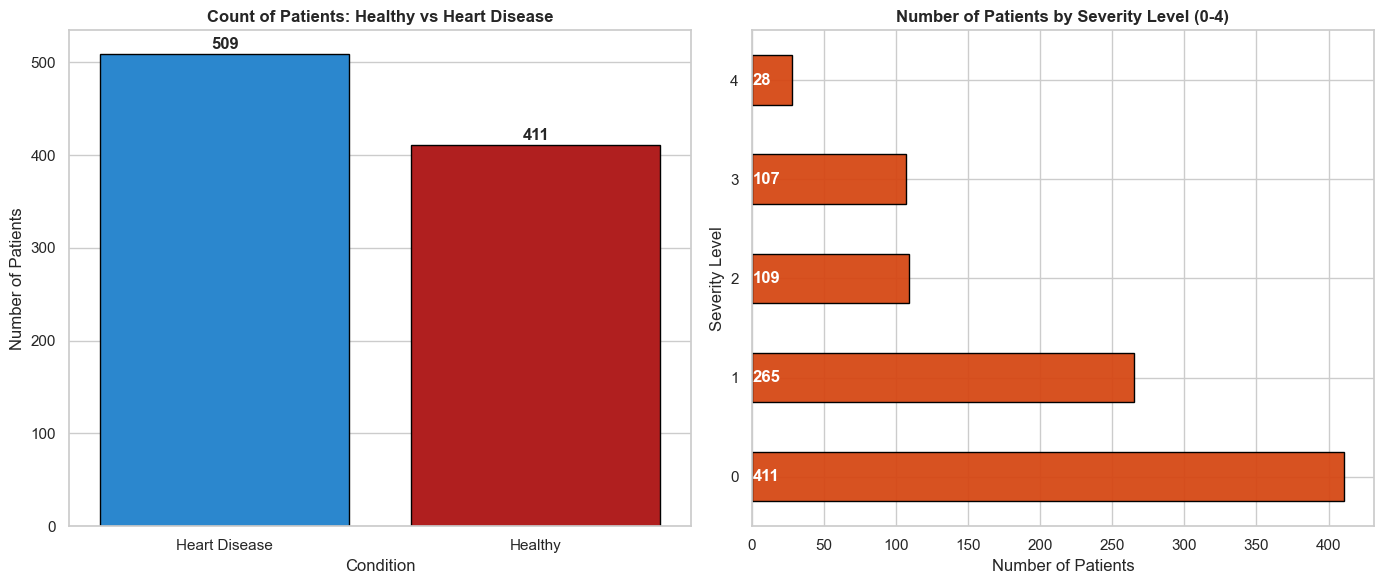

In [84]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(14,6))

# Grouping levels 1, 2, 3, and 4 into a single "Heart Disease" group: 0 remains "Healthy", everything > 0 is classified as "Heart Disease"
binary_data = df['target'].apply(lambda x: 'Heart Disease' if x > 0 else 'Healthy').value_counts()
sns.barplot(x=binary_data.index, y=binary_data.values, ax=ax1, palette=['#108BE9','#C80707'], edgecolor='black')
for i, v in enumerate(binary_data.values):
    ax1.text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

ax1.set_title('Count of Patients: Healthy vs Heart Disease', fontweight='bold')
ax1.set_xlabel('Condition')
ax1.set_ylabel('Number of Patients')

# Showing the 5 original levels to visualize disease severity
severity_counts = df["target"].value_counts().sort_index()
ax2 = severity_counts.plot(kind="barh", ax=ax2, color="#D54511EE", edgecolor='black')
for i, j in enumerate(severity_counts.values):
    ax2.text(0.5, i, str(j), fontsize=12, color='white', weight='bold', va='center')

ax2.set_title('Number of Patients by Severity Level (0-4)', fontweight='bold')
ax2.set_xlabel('Number of Patients')
ax2.set_ylabel('Severity Level')

plt.tight_layout()
plt.show()

**Binary Classification: Healthy vs Heart Disease**  

The first plot shows the dataset split into two groups after transforming the multi-class target into a binary classification:

- **Heart Disease (1–4)**: 55.3%  
- **Healthy (0)**: 44.7%  

The dataset is relatively balanced with a slight majority of heart disease patients (55/45 split). This balance reduces the risk of bias toward the majority class and eliminates the need for aggressive resampling techniques.

---

**Severity Level Distribution**  

The second plot breaks down the target variable into its original five levels:

| Severity Level | Percentage | Clinical Interpretation |
|----------------|------------|------------------------|
| 0 | 44.7% | No heart disease (healthy) |
| 1 | 28.8% | Mild heart disease |
| 2 | 11.8% | Moderate heart disease |
| 3 | 11.6% | Moderate-to-severe heart disease |
| 4 | 3.0% | Severe heart disease |

This distribution shows a natural clinical pattern: prevalence decreases as severity increases. Levels 3 and 4 together represent only **14.6%** of the dataset, with level 4 accounting for just **3%** of patients (28 individuals).

---

**Methodology: From Multi-class to Binary**  

The multi-class target (0–4) is transformed into two categories: 'Healthy' or 'Heart Disease'. This is done for several reasons:

- *Clinical relevance*: Screening typically focuses on detecting any heart disease, not specific severity levels.  
- *Model robustness*: Binary classification handles class imbalance more effectively, especially with limited data in severe categories.  
- *Data efficiency*: Combining severe and milder cases increases the positive class size, improving statistical power.

**Implications for Modeling**

- *Multi-class prediction*: Severe cases (levels 3–4) are underrepresented (~15%), requiring careful evaluation. Metrics such as recall and F1-score should be monitored.  
- *Binary classification*: The 55/45 split allows standard models to perform reliably, with evaluation via accuracy and AUC-ROC.

This approach balances **clinical relevance**—screening for any heart disease—with **model robustness**, efficiently leveraging limited severe-case data.

---

#### **2.2: Demographic Analysis: Age and Gender Distribution**

These plots illustrate how age and gender influence both the presence and severity of heart disease across the patient population.

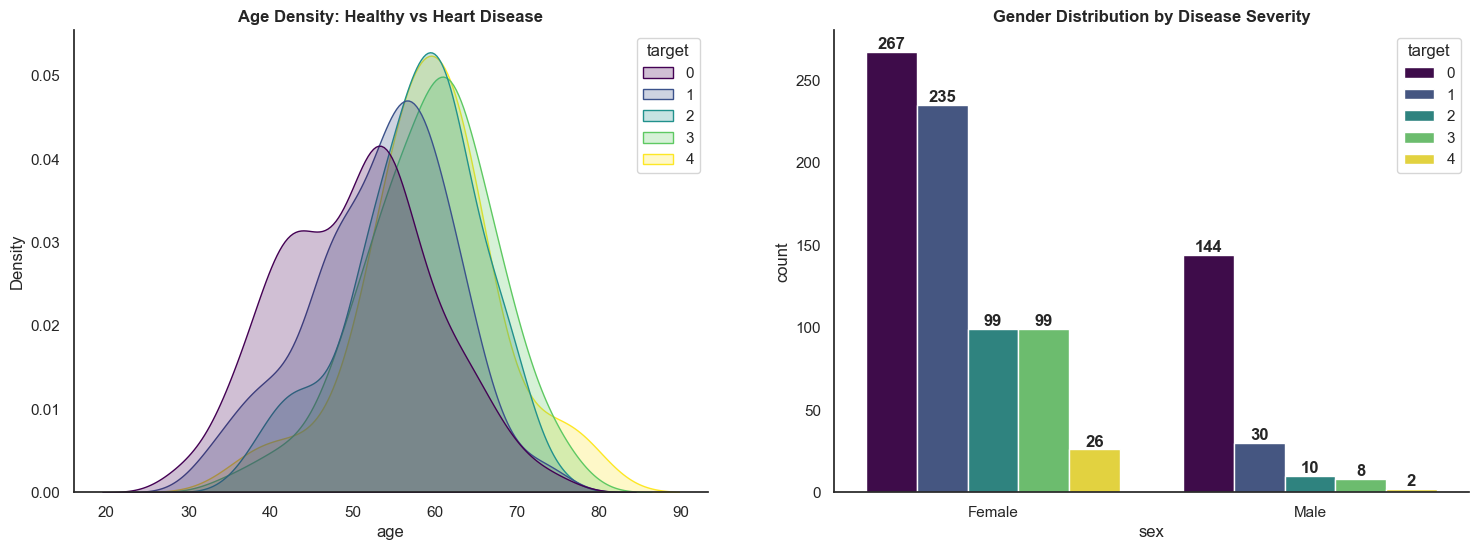

In [85]:
plt.figure(figsize=(18, 6))
sns.set_style("white")

# Age distribution
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='age', hue='target', fill=True, palette='viridis', common_norm=False)
plt.title('Age Density: Healthy vs Heart Disease', fontweight='bold')

# Gender impact
plt.subplot(1, 2, 2)
ax = sns.countplot(data=df, x='sex', hue='target', palette='viridis')
plt.title('Gender Distribution by Disease Severity', fontweight='bold')
plt.xticks([0, 1], ['Female', 'Male'])
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

sns.despine()
plt.show()

**Age Density Distribution**

The left plot shows the age distribution for each disease severity level using kernel density estimation, with each curve normalized independently to highlight patterns rather than counts.

**Key Observations**

| Severity Level | Age Peak    | Distribution Shape                      |
| -------------- | ----------- | --------------------------------------- |
| Healthy (0)    | 55–60 years | Concentrated in middle age              |
| Mild (1)       | 60–65 years | Shift toward older ages                 |
| Moderate (2)   | 65–70 years | Further right shift                     |
| Severe (3–4)   | 70+ years   | Highest concentration among the elderly |

Age is a progressive cardiovascular risk factor: higher disease severity corresponds to older age groups. Healthy patients are mainly between 45–65 years, while severe cases (levels 3–4) occur mostly in individuals over 65. Overall, heart disease appears between about 40–75 years, with the highest concentration between 50–70. This pattern confirms established medical evidence that both prevalence and severity increase with age.

---

**Gender Distribution by Disease Severity**

The right plot displays patient counts by gender and severity level, with exact values shown on each bar.

**Dataset Composition and Key Observations**

| Gender | Total (%) | Healthy | Any Disease | Severe (3–4) |
| ------ | --------- | ------- | ----------- | ------------ |
| Female | 29%       | 235     | 32          | 14 (5.2%)    |
| Male   | 71%       | 144     | 509         | 100 (15.3%)  |

The dataset reveals a strong gender disparity in heart disease. Among women, 88% are healthy and 12% have the disease, with severe cases affecting only 5.2%; when present, disease is distributed fairly evenly across levels 1–3. In contrast, men show much higher prevalence: 78% have heart disease and only 22% are healthy. Mild disease (level 1) is the largest group among men (301 patients), while severe cases (levels 3–4) affect 100 men (15.3%), with 208 patients in moderate-to-severe stages (levels 2–4). This reflects known clinical patterns: men have higher cardiovascular risk, develop the disease about 7–10 years earlier, and more often progress to severe stages. The large gap (78% of men vs 12% of women) is consistent with the protective effect of estrogen before menopause and the typically later onset of cardiovascular disease in women.

---

#### **2.3: Categorical Features Impact on Heart Disease Probability**

This analysis examines the relationship between three key clinical features and heart disease probability. For each categorical variable, the proportion of healthy patients versus those with heart disease is calculated to identify which characteristics serve as stronger risk indicators.

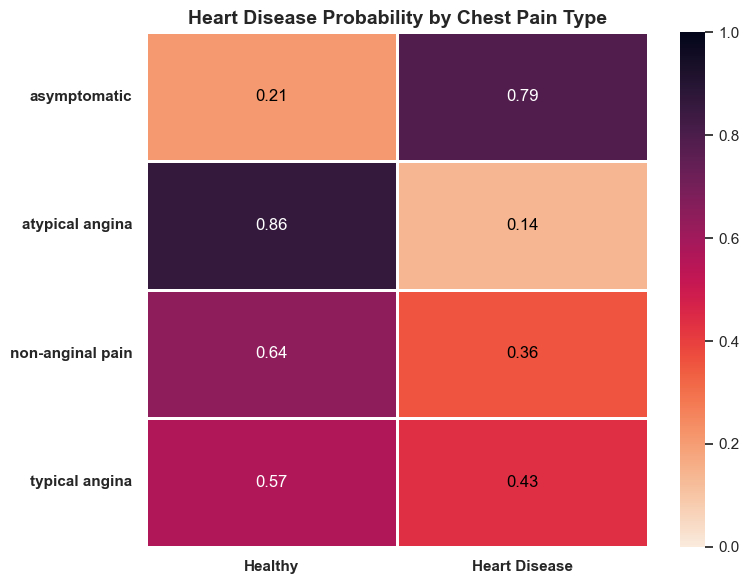

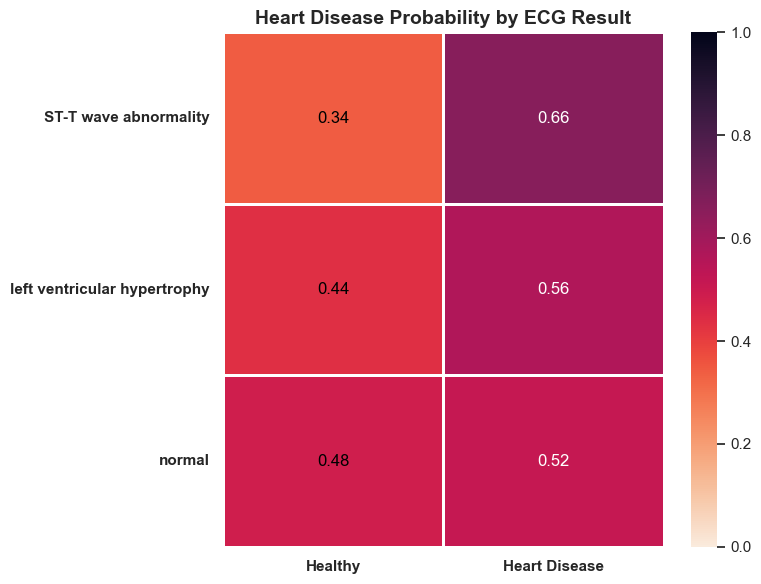

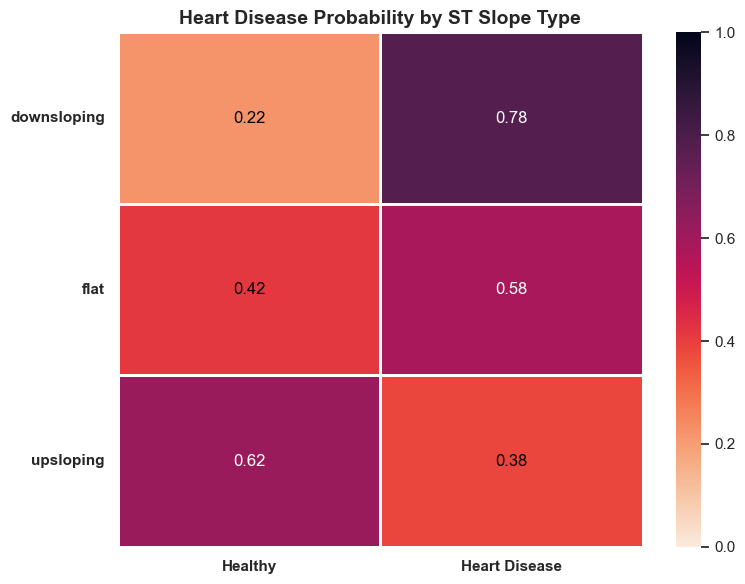

In [86]:
def plot_heatmap_probability(data, column, labels_dict, title):
    df = data.copy()
    # Convert multi-class target (0-4) to binary classification: 0 = Healthy, any value >0 = Heart Disease
    df['Condition'] = df['target'].map(lambda x: 'Heart Disease' if x > 0 else 'Healthy')
    ct = pd.crosstab(df[column], df['Condition'], normalize='index')
    ct.index = [labels_dict.get(x, x) for x in ct.index]
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(ct, annot=True, fmt=".2f", cmap="rocket_r",
                     vmin=0, vmax=1, linewidths=0.8, linecolor="white")
    for text in ax.texts:
        value = float(text.get_text())
        text.set_color("white" if value > 0.5 else "black")
    
    plt.title(title, fontweight='bold', fontsize=14)
    plt.ylabel("")
    plt.xlabel("")
    plt.xticks(fontweight='bold')
    plt.yticks(rotation=0, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Clinical label mappings for interpretability: convert the dataset's numeric codes into medical terminology
cp_labels = {1.0: 'Typical Angina', 2.0: 'Atypical Angina', 
             3.0: 'Non-anginal Pain', 4.0: 'Asymptomatic'}
ecg_labels = {0.0: 'Normal', 1.0: 'ST-T Abnormality', 2.0: 'LV Hypertrophy'}
slope_labels = {1.0: 'Upsloping', 2.0: 'Flat', 3.0: 'Downsloping'}

# Generate visualizations for three key clinical features
plot_heatmap_probability(df, 'cp', cp_labels, "Heart Disease Probability by Chest Pain Type")
plot_heatmap_probability(df, 'restecg', ecg_labels, "Heart Disease Probability by ECG Result")
plot_heatmap_probability(df, 'slope', slope_labels, "Heart Disease Probability by ST Slope Type")

**Chest Pain Type**

Asymptomatic patients show the highest disease probability (79%), suggesting that **silent ischemia** can occur even without symptoms. **Typical angina** has a 43% probability, indicating that classic symptoms do not always correspond to actual heart disease. **Atypical angina** shows the lowest association (14%), often reflecting non-cardiac causes such as musculoskeletal issues, reflux, or anxiety. Overall, symptoms alone are unreliable predictors, and the absence of chest pain does not exclude disease.

---

**ECG Result**

All ECG categories show disease probabilities above 50%, indicating that a resting ECG alone cannot rule out heart disease. ST-T abnormalities show the strongest association (66%), while LVH (56%) reflects structural changes linked to hypertension and increased cardiovascular risk. Even patients with a normal ECG have a 52% probability of disease, highlighting that a normal result does not exclude significant coronary artery disease.

---

**ST Slope Type**

ST slope shows the clearest gradient in disease probability. **Downsloping segments** have the highest probability (78%) and strongly suggest ischemia. **Flat segments** show a moderate association (58%) and remain clinically concerning. **Upsloping segments** have the lowest probability (38%) and are more often considered a normal variant. This pattern supports the established hierarchy used in interpreting exercise ECG results.

---

#### **2.4: Numerical Features Analysis**

The boxplots show the distribution of three numerical features for healthy patients and those with heart disease. Each plot highlights the median, quartiles, and outliers, allowing comparison between the two groups.

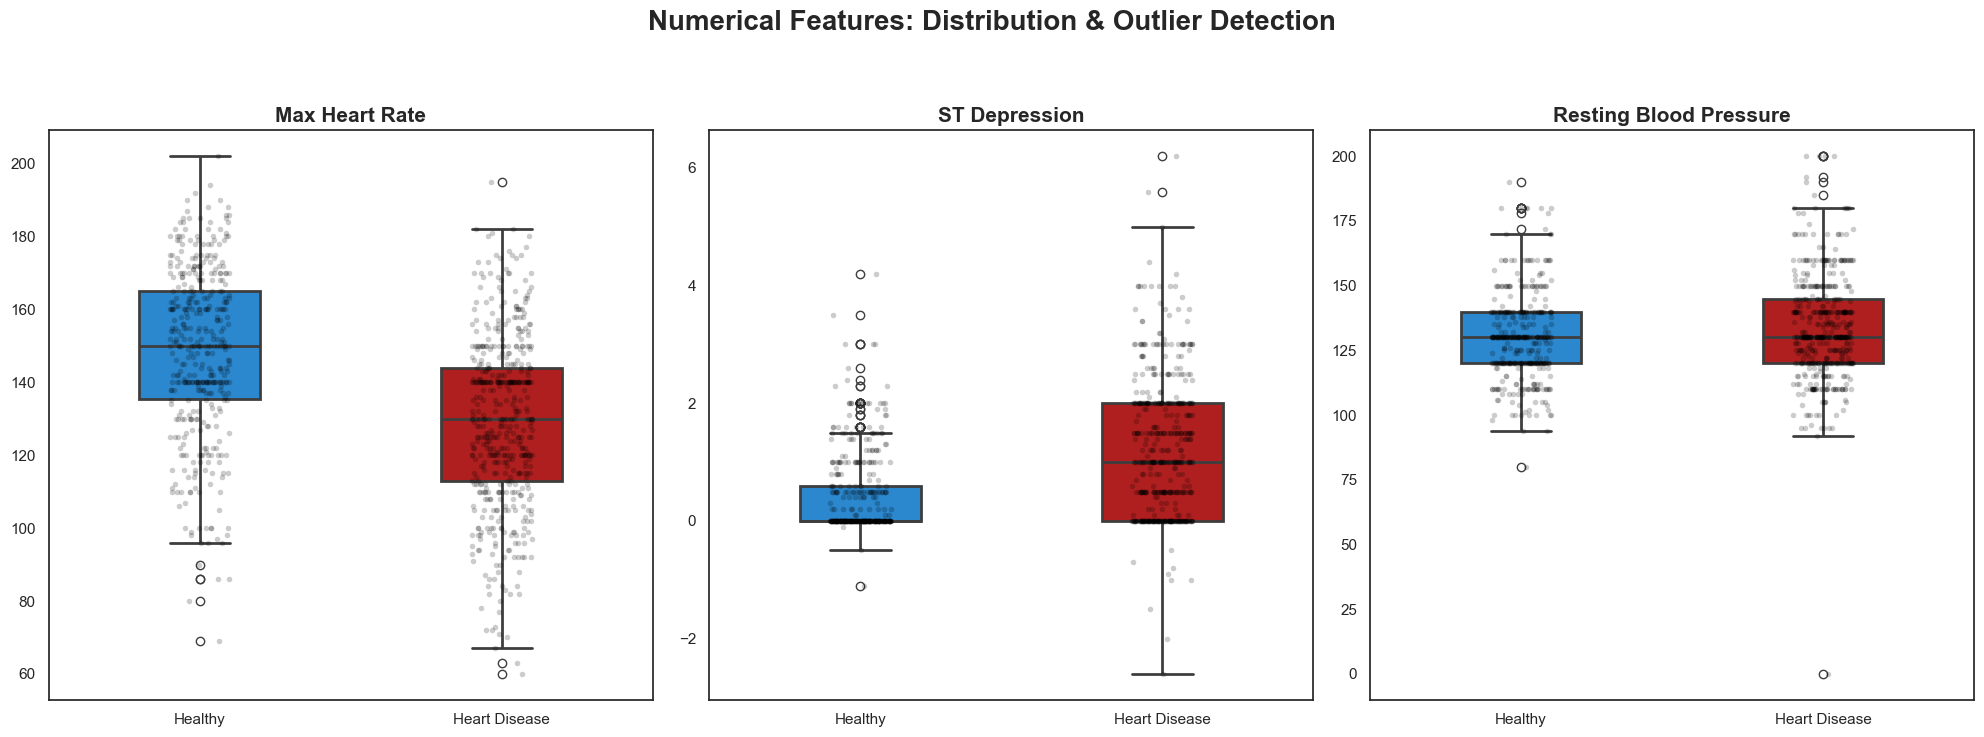

In [87]:
df['Condition'] = df['target'].apply(lambda x: 'Heart Disease' if x > 0 else 'Healthy')

features = ['thalach', 'oldpeak', 'trestbps']
titles = ['Max Heart Rate', 'ST Depression', 'Resting Blood Pressure']
colors = {'Healthy': "#108BE9", 'Heart Disease': "#C80707"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.set_theme(style="whitegrid")

for i, var in enumerate(features):
    sns.boxplot(data=df, x='Condition', y=var, ax=axes[i], 
                palette=colors, width=0.4, linewidth=2, hue='Condition', legend=False)
    sns.stripplot(data=df, x='Condition', y=var, ax=axes[i], 
                  color='black', alpha=0.2, size=4)
    axes[i].set_title(titles[i], fontsize=15, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Numerical Features: Distribution & Outlier Detection', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Max Heart Rate**

The maximum heart rate reached during exercise testing, reflecting cardiovascular fitness and the heart’s ability to respond to stress.

* **Healthy patients** have higher median heart rates and a wider distribution
* **Heart disease patients** show lower and more concentrated values
* Outliers are present in both groups, slightly more frequent in the disease group

The lower maximum heart rate in disease patients suggests reduced cardiac efficiency and impaired chronotropic response. Cardiovascular disease can limit the heart’s ability to increase its rate during exertion, reducing exercise tolerance. In contrast, healthy individuals show greater variability and generally higher peak rates, reflecting better cardiac performance.

---

**ST Depression**

ST segment depression during exercise compared to rest, measured in millimeters. Higher values indicate myocardial ischemia during stress.

* **Heart disease patients** show clearly higher ST depression values
* **Healthy patients** cluster near zero with little variation
* Several extreme outliers appear in the disease group

ST depression is a strong electrocardiographic indicator of ischemia. The clear separation between groups confirms its diagnostic relevance: disease patients show elevated values while healthy individuals remain near zero. These changes occur when narrowed coronary arteries cannot supply enough oxygen during exercise, and extreme values may indicate severe or multi-vessel coronary disease.

---

**Resting Blood Pressure**

Blood pressure measured at rest before exercise testing, expressed in mm Hg. Elevated values are associated with hypertension.

* **Both groups** have similar median values and distributions
* **Healthy patients** show slightly wider spread at higher values
* Outliers appear in both groups

Resting blood pressure shows little separation between healthy and diseased patients. Similar medians and interquartile ranges suggest limited diagnostic power when used alone. This may reflect the episodic nature of hypertension and the effect of medication in treated patients. Consequently, resting blood pressure is better interpreted as a long-term risk factor rather than a direct indicator of existing heart disease.

---

### **Step 3: Data Preparation**

This section transforms the data into a format suitable for machine learning algorithms. The operations performed here are critical for model performance and reliability.

#### **3.1: Outlier Detection and Removal**

Before training the models, outliers are identified and removed from the numerical features. Extreme values can negatively affect model performance, especially for algorithms sensitive to data scale such as Support Vector Machines (SVM) and Logistic Regression.

**Outliers** are observations that differ significantly from the rest of the dataset. They may result from measurement errors, data entry issues, or genuine extreme cases. In medical datasets, examples include unusually high cholesterol levels or extremely low maximum heart rates. If not handled, these values can distort statistical measures and bias machine learning models.

Outliers are detected using the **Z-score method**, which measures how many standard deviations a value deviates from the mean:

```
Z-score = (X - μ) / σ
```

Where:

* `X` = data point
* `μ` = mean of the feature
* `σ` = standard deviation of the feature

A threshold of **|Z| > 3** is used to identify outliers. This choice is statistically justified because, in a normal distribution, approximately **99.7% of observations fall within three standard deviations of the mean**.

In [88]:
# Subset of the DataFrame containing only numerical features 
df_numeric = df[['age', 'trestbps', 'chol', 'thalach']]
df_numeric.head()

,age,trestbps,chol,thalach
0,63.0,145.0,233.0,150.0
1,67.0,160.0,286.0,108.0
2,67.0,120.0,229.0,129.0
3,37.0,130.0,250.0,187.0
4,41.0,130.0,204.0,172.0


**Calculating z-score of numeric columns**

The Z-score is computed for all numerical features using the `stats.zscore()` function from the SciPy library.

The absolute value (`np.abs`) is applied in order to consider extreme deviations in both positive and negative directions.

The resulting matrix contains the Z-score values for each observation and will be used to identify potential outliers in the dataset.

In [89]:
z = np.abs(stats.zscore(df_numeric))
print(z)

[[1.00738556 0.70517639 0.30364317 0.4897271 ]
 [1.43203377 1.51856943 0.78996695 1.18147797]
 [1.43203377 0.65047866 0.26693949 0.34587544]
 ...
 [0.15808914 0.54202626 0.21188397 1.49980275]
 [0.4765753  0.10821664 1.69838307 0.09182113]
 [0.90122351 0.65047866 0.4963375  1.77833693]]


**Defining threshold for filtering outliers**

A threshold value of 3 is defined to identify potential outliers.

The function `np.where(z > 3)` is used to identify the indices of the values that exceed this threshold.

In [90]:
threshold = 3
print(np.where(z > 3))

(array([126, 152, 188, 338, 528, 546, 548, 631, 680, 701, 753, 896]), array([1, 2, 1, 1, 2, 2, 1, 3, 1, 1, 1, 1]))


**Removing Outliers**

The dataset is filtered to retain only the observations whose Z-score values are below the defined threshold.

The condition `(z < 3).all(axis=1)` ensures that each retained row does not contain any feature with a Z-score greater than the threshold.

In [91]:
df = df[(z < 3).all(axis=1)]

**Encoding Categorical Variables**

Categorical variables are converted into numerical format using one-hot encoding, implemented through the `pd.get_dummies()` function. The parameter `drop_first=True` removes the first category of each variable in order to avoid multicollinearity (dummy variable trap).

After this transformation, all variables in the dataset are represented numerically and are suitable for use in machine learning algorithms.

In [92]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,trestbps,chol,fbs,thalach,exang,oldpeak,ca,thal,target,sex_male,cp_atypical angina,cp_non-anginal pain,cp_typical angina,restecg_left ventricular hypertrophy,restecg_normal,slope_flat,slope_upsloping,Condition_Heart Disease
0,63.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,6.0,0,True,False,False,True,True,False,False,False,False
1,67.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,3.0,2,True,False,False,False,True,False,True,False,True
2,67.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,7.0,1,True,False,False,False,True,False,True,False,True
3,37.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,3.0,0,True,False,True,False,False,True,False,False,False
4,41.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,3.0,0,False,True,False,False,True,False,False,True,False


In [93]:
df.shape

(908, 19)

#### **3.2: Train-Test Split**

The dataset is first split into training and testing sets to prevent the test data from influencing preprocessing. Applying normalization or feature selection beforehand would cause data leakage, giving the model indirect access to evaluation data and inflating performance. 

Splitting first ensures preprocessing uses only the training data, keeping evaluation unbiased and reflecting true generalization.

**Feature and Target Separation**

The dataset is first divided into predictor variables and the target variable. 
All columns except `target` are assigned to `X`, which contains the input features used by the model, while the `target` column is assigned to `y`, representing the outcome to be predicted.

In [94]:
X = df.drop(['target'],axis=1)
y = df['target']

The data is then split into training and testing subsets using the `train_test_split()` function from scikit-learn. 

This step allows the model to be trained on one portion of the data while reserving a separate subset for performance evaluation.

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2,shuffle=True, random_state=5)

A fixed `random_state` is specified to ensure that the dataset is split in the same way each time the code is executed, guaranteeing consistent and reproducible results.

In [96]:
# Checking distribution of target variable in train test split
print('Distribution of target variable in training set')
print(y_train.value_counts())

Distribution of target variable in training set
target
0    327
1    209
2     86
3     82
4     22
Name: count, dtype: int64


In [97]:
print('Distribution of target variable in test set')
print(y_test.value_counts())

Distribution of target variable in test set
target
0    82
1    52
2    22
3    21
4     5
Name: count, dtype: int64


In [98]:
y_train_bin = (y_train > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

In [99]:
# Save training and test set 
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

---

### **Step 4: Feature Engineering**

After proper data cleaning and structuring, feature engineering refines the feature space to enhance model performance. This involves **normalization** to balance feature contributions and **feature selection** to retain the most predictive variables, thereby improving the ability of algorithms to identify patterns linked to cardiovascular disease.

#### **4.1: Feature Normalization**

Feature normalization rescales numerical values onto a common range without altering their relative differences. This is crucial when features vary in units or magnitude, as many machine learning algorithms—especially distance- or gradient-based methods—tend to give undue weight to features with larger numeric values.


Before normalization, the `Condition_Heart Disease` column—representing the binary target—is removed from the feature set to prevent target leakage, which could bias model training.

In [100]:
X_train_clean = X_train.drop(columns=['Condition_Heart Disease'], errors='ignore')
X_test_clean = X_test.drop(columns=['Condition_Heart Disease'], errors='ignore')

The dataset’s numerical features span widely different ranges. Without normalization, variables like `chol` (serum cholesterol, 126–564 mg/dL) would dominate over features like `ca` (number of major vessels, 0–3), potentially skewing model learning and degrading performance.

**Feature ranges:**

| Feature    | Range   | Unit  |
| ---------- | ------- | ----- |
| `age`      | 29–77   | years |
| `trestbps` | 94–200  | mm Hg |
| `chol`     | 126–564 | mg/dL |
| `thalach`  | 71–202  | bpm   |
| `oldpeak`  | 0–6.2   | mm    |
| `ca`       | 0–3     | count |
| `thal`     | 3–7     | code  |


**Normalization method:** Min-Max scaling transforms all numerical features to the [0, 1] range:

`X(scaled) = (X - X(min)) / (X(max) - X(min))`

In [101]:
cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
scaler = MinMaxScaler()

In [102]:
X_train_scaled = X_train_clean.copy()
X_test_scaled = X_test_clean.copy()

**Implementation**


| Function          | Applied to                     | Role                                                            |
| ----------------- | ------------------------------ | --------------------------------------------------------------- |
| `fit_transform()` | Training set (`X_train_clean`) | Computes minima and maxima, applies scaling to training data    |
| `transform()`     | Test set (`X_test_clean`)      | Applies the same scaling using parameters from the training set |


In [103]:
X_train_scaled[cols] = scaler.fit_transform(X_train_clean[cols])
X_test_scaled[cols] = scaler.transform(X_test_clean[cols])

In [104]:
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

#### **4.2: Feature Selection**

Feature selection identifies the most relevant variables for the predictive model. Removing irrelevant or redundant features improves model performance, reduces overfitting and helps identify the most important clinical risk factors.

**Random Forest Feature Importance** was used as an **embedded feature selection method** to evaluate the contribution of each predictor to the model's performance. This method derives importance directly from the trained ensemble of decision trees.

1. A **Random Forest classifier** with 100 trees (`n_estimators=100`, `random_state=42`) was trained on all 17 clinical features.
2. Feature importance was computed using **Mean Decrease in Impurity (Gini importance)**, which measures how much each feature reduces node impurity across all trees.
3. The resulting importance scores were **normalized and ranked**, producing a continuous hierarchy of features from most to least predictive.
4. The results were visualized with horizontal bar plots to support the final feature selection.

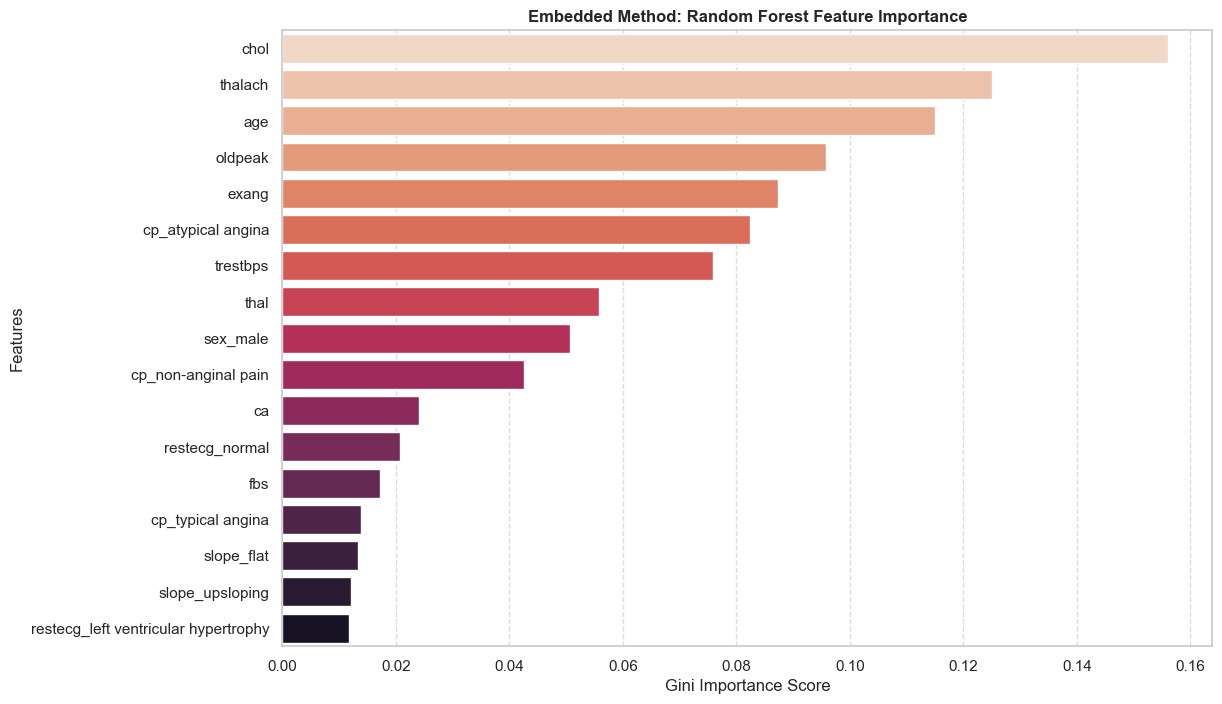

Full Feature Ranking:
                                 Feature  Importance
2                                   chol    0.156052
4                                thalach    0.125077
0                                    age    0.114915
6                                oldpeak    0.095856
5                                  exang    0.087356
10                    cp_atypical angina    0.082454
1                               trestbps    0.075887
8                                   thal    0.055803
9                               sex_male    0.050715
11                   cp_non-anginal pain    0.042511
7                                     ca    0.024133
14                        restecg_normal    0.020784
3                                    fbs    0.017273
12                     cp_typical angina    0.013930
15                            slope_flat    0.013355
16                       slope_upsloping    0.012154
13  restecg_left ventricular hypertrophy    0.011743


In [105]:
#  Initialize and fit the Random Forest on all 17 features - binary target (y_train_bin)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_bin)

# Extract feature importance
importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='rocket_r')
plt.title('Embedded Method: Random Forest Feature Importance', fontweight='bold')
plt.xlabel('Gini Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Full Feature Ranking:")
print(importances)

**Feature Importance Summary**

The Random Forest analysis identifies a clear hierarchy of predictors for cardiovascular disease, combining statistical relevance with clinical interpretability.

| Tier | Features | Importance Range | Clinical Significance |
|------|----------|------------------|----------------------|
| **Top Tier** | `chol`, `thalach`, `age` | >0.10 | Dominant predictors: lipid accumulation, cardiac performance under stress, and cumulative risk |
| **Second Tier** | `oldpeak`, `exang`, `cp_atypical angina` | 0.08–0.10 | Indicators of exercise-induced ischemia and atypical symptom patterns |
| **Third Tier** | `trestbps`, `thal`, `sex_male`, `cp_non-anginal pain` | 0.04–0.08 | Moderate contributors: hemodynamic, perfusion, and demographic factors |
| **Lower Tier** | `ca`, `restecg`, `fbs`, `cp_typical angina`, slope features | <0.04 | Limited predictive value |

Rather than acting independently, these features collectively describe three complementary dimensions of cardiovascular risk. Metabolic factors—primarily cholesterol—capture long-term disease development, while exercise-related variables reflect functional cardiac capacity and the presence of inducible ischemia. Demographic and clinical context, including age and sex, further modulate baseline risk.

Lower-importance variables were excluded to improve model efficiency, as they provided minimal additional predictive signal.

Overall, the model prioritizes a compact set of clinically meaningful features, achieving a balance between predictive performance and interpretability without unnecessary redundancy.

---

### **Step 5: Model Training**

After preprocessing and feature selection, several machine learning models were trained to predict the presence of cardiovascular disease. Four classification algorithms were evaluated: **Logistic Regression**, **Gaussian Naive Bayes**, **Support Vector Machine (SVM)** and **Random Forest**.

Each model was trained using the selected features and the binary target variable (`y_train_bin`), which indicates the presence or absence of heart disease. This approach enables a consistent comparison of the models’ ability to accurately distinguish between healthy individuals and patients with cardiovascular disease.


In [106]:
# Select top 10 features based on Random Forest importance for final model training
top_10_features = importances.head(10)['Feature'].tolist()

X_train_final = X_train_scaled[top_10_features]
X_test_final = X_test_scaled[top_10_features]

print(f"Features selected: {top_10_features}")

Features selected: ['chol', 'thalach', 'age', 'oldpeak', 'exang', 'cp_atypical angina', 'trestbps', 'thal', 'sex_male', 'cp_non-anginal pain']


A set of complementary scoring metrics was defined to provide a comprehensive evaluation of the model’s performance:

In [107]:
# Evaluation Metrics
scorers = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1_macro': make_scorer(f1_score, average='macro'),
    'mcc': make_scorer(matthews_corrcoef),
    'roc_auc': 'roc_auc'
}

#### **5.1: Logistic Regression**

Logistic Regression models the probability that a given sample belongs to the positive class using the logistic function. Despite its name, it is a classification algorithm that estimates class probabilities through a linear decision boundary.

In [108]:
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], 
    'penalty': ['l2'],                       
    'solver': ['liblinear', 'lbfgs']         
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_final, y_train_bin)

print("Best C found:", lr_grid.best_params_['C'])
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_bin, lr_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best C found: 10

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

      Healthy       0.86      0.80      0.83        82
Heart Disease       0.85      0.89      0.87       100

     accuracy                           0.85       182
    macro avg       0.85      0.85      0.85       182
 weighted avg       0.85      0.85      0.85       182



**Hyperparameter Tuning:**

- **`C` (Inverse Regularization Strength)**: Controls the trade-off between fitting the training data and keeping model weights small. Smaller values specify stronger regularization, helping prevent overfitting. The search range spans from very strong regularization (0.001) to very weak (100).
- **`penalty`**: Specifies the regularization type. L2 regularization (ridge) penalizes the sum of squared weights, encouraging small but non-zero coefficients.
- **`solver`**: Algorithm used for optimization. `liblinear` works well for smaller datasets, while `lbfgs` is more efficient for larger problems.

**GridSearchCV Configuration:**
- **`scoring='roc_auc'`**: Optimizes for the Area Under the ROC Curve, measuring the model's ability to distinguish between classes independently of the classification threshold.
- **`cv=5`**: Uses 5-fold cross-validation to evaluate each parameter combination
- **`n_jobs=-1`**: Parallelizes computation across all available CPU cores.

---

*Interpretation:*

- The optimal regularization strength **`C=10`** indicates relatively weak regularization, allowing the model to fit the data without excessive constraint on coefficients

- **Balanced performance** across both classes with precision and recall values in the 0.80-0.89 range

- **Higher recall for heart disease (0.89)** than for healthy (0.80), indicating better sensitivity for detecting disease—a favorable characteristic for medical screening

- **Macro F1-score of 0.85** confirms consistent performance across both classes

- **Accuracy of 85%** with similar precision for both classes (0.86 Healthy, 0.85 Heart Disease) suggests the model avoids bias toward the majority class

---

#### **5.2: Gaussian Naive Bayes**

Gaussian Naive Bayes applies Bayes' theorem with the assumption that continuous features follow a normal (Gaussian) distribution. Despite its "naive" assumption of feature independence, it often performs well on medical data where features may have complex relationships.

In [109]:
gnb_params = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

gnb_grid = GridSearchCV(
    GaussianNB(),
    gnb_params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

gnb_grid.fit(X_train_final, y_train_bin)

print("Best var_smoothing found:", gnb_grid.best_params_['var_smoothing'])
print("\nClassification Report (Gaussian Naive Bayes):")
print(classification_report(y_test_bin, gnb_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best var_smoothing found: 1e-09

Classification Report (Gaussian Naive Bayes):
               precision    recall  f1-score   support

      Healthy       0.85      0.82      0.83        82
Heart Disease       0.85      0.88      0.87       100

     accuracy                           0.85       182
    macro avg       0.85      0.85      0.85       182
 weighted avg       0.85      0.85      0.85       182



**Hyperparameter Tuning:**

- **`var_smoothing`**: Adds a small value to the diagonal of feature variance estimates to prevent numerical instability. This parameter controls the amount of smoothing applied to variance calculations, with larger values providing more stability but potentially reducing sensitivity. The search range spans from minimal smoothing (1e-9) to more aggressive smoothing (1e-5).

---

*Interpretation:*

- Optimal smoothing **`1e-9`** indicates stable variance estimates without need for regularization

- **Results nearly identical to Logistic Regression** with 85% accuracy and 0.85 Macro F1

- Slightly higher recall for heart disease (0.88) than healthy (0.82)

- Demonstrates that the naive independence assumption does not harm predictions for this dataset

---

#### **5.3: Support Vector Machine (SVM)**

Support Vector Machine finds the optimal hyperplane that maximally separates classes in a transformed feature space. The radial basis function (RBF) kernel allows non-linear decision boundaries by mapping features into a higher-dimensional space.

In [110]:
svm_params = {'C': list(range(1, 11)), 'kernel': ['rbf']}
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
svm_grid.fit(X_train_final, y_train_bin)

print("Best C found:", svm_grid.best_params_['C'])
print("\nClassification Report (SVM):")
print(classification_report(y_test_bin, svm_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best C found: 1

Classification Report (SVM):
               precision    recall  f1-score   support

      Healthy       0.88      0.77      0.82        82
Heart Disease       0.83      0.91      0.87       100

     accuracy                           0.85       182
    macro avg       0.85      0.84      0.84       182
 weighted avg       0.85      0.85      0.84       182



**Hyperparameter Tuning:**

- **`C` (Regularization Parameter)**: Controls the trade-off between achieving a low error on training data and maximizing the margin. Smaller values create wider margins with more misclassifications (simpler models), while larger values aim to classify all training points correctly (potentially overfitting). The search explores values from 1 to 10.
- **`kernel`**: Specifies the transformation function. RBF (radial basis function) is selected for its flexibility in creating non-linear decision boundaries.
- **`probability=True`**: Enables probability estimates, allowing ROC curve analysis and probability-based predictions.

---

*Interpretation:*

- Optimal `C=1` represents represents relatively strong regularization, keeping the decision boundary simpler.

- **High sensitivity for heart disease (0.91)** – the model correctly identifies 91% of actual disease cases, excellent for screening purposes

- Trade-off evident: this high recall comes at the cost of lower recall for healthy patients (0.77), meaning more false positives

- Best precision for healthy class (0.88)– when SVM predicts healthy, it's highly reliable

- Accuracy of 85% matches Logistic Regression and Naive Bayes, despite the different performance profile

- The SVM prioritizes **detecting disease over avoiding false alarms**, which is clinically appropriate for medical screening

---

#### **5.4: Random Forest**

Random Forest builds an ensemble of decision trees on bootstrap samples of the data, introducing randomness through both sample selection and feature subsampling at each split. The final prediction is aggregated across all trees (majority voting).

In [111]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_final, y_train_bin)

print("Best Parameters found:", rf_grid.best_params_)
print("\nClassification Report:")
print(classification_report(y_test_bin, rf_grid.predict(X_test_final), target_names=['Healthy', 'Heart Disease']))

Best Parameters found: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.90      0.76      0.82        82
Heart Disease       0.82      0.93      0.87       100

     accuracy                           0.85       182
    macro avg       0.86      0.84      0.85       182
 weighted avg       0.86      0.85      0.85       182



**Optimal Parameters:**
  - `max_depth=5`: Restricting tree depth prevents overfitting while capturing sufficient complexity
  - `min_samples_split=5`: Higher than default (2) indicates the model benefits from preventing splits on very small samples, reducing overfitting
  - `n_estimators=100`: Sufficient for convergence; adding more trees (200, 300) did not improve performance

- *Interpretation:*
  - **Highest recall for heart disease (0.93)** – identifies 93% of actual disease cases, best among all models for sensitivity

  - Excellent precision for healthy class (0.90) – when predicting healthy, it's correct 90% of the time

  - Clear sensitivity-specificity trade-off: high recall (0.93) for disease vs lower recall for healthy (0.76), prioritizing detection of positive cases

  - Accuracy of 85% matches other models, but with a more clinically favorable error profile

  - Macro F1 of 0.85 confirms balanced performance across classes

---

**Consideration**

- **Random Forest emerges as the best model for clinical screening**, achieving the highest recall (0.93) and strong precision, making it most suitable for minimizing false negatives

- **All models demonstrate strong predictive capability** with ROC-AUC scores exceeding 0.90 for three out of four models

- **SVM offers an interesting alternative** with excellent recall (0.91) and the highest ROC-AUC (0.9130), but at the cost of more false positives

- **Simpler models remain highly competitive** – Logistic Regression and Naive Bayes achieve 85% accuracy with balanced performance, proving that complex models aren't always necessary

- **The sensitivity-specificity trade-off varies across algorithms**, allowing model selection based on clinical priorities:
  - **Random Forest**: Best for screening (prioritizes finding sick patients)
  - **SVM**: Excellent discrimination with good sensitivity
  - **Logistic Regression/Naive Bayes**: Balanced, interpretable options

---

### **Step 6: Model Evaluation and Comparison**

After training all four models with optimized hyperparameters, a comprehensive evaluation was conducted to compare their performance on the test set. This section presents the results and provides detailed interpretation of each model's strengths and weaknesses.

**Evaluation Metrics**

The following metrics were used to evaluate model performance:

- *Accuracy:* Overall proportion of correct predictions

- *Recall (Sensitivity):* Ability to correctly identify patients with heart disease (true positive rate)

- *Macro F1-Score:* Harmonic mean of precision and recall, averaged across both classes

- *Matthews Correlation Coefficient (MCC):* A balanced measure of binary classification quality, ranging from -1 (total disagreement) to +1 (perfect prediction), with 0 indicating random guessing

- *ROC-AUC:* Area Under the Receiver Operating Characteristic curve, measuring the model's ability to discriminate between classes across all classification thresholds

In [112]:
final_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Gaussian Naive Bayes": gnb_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_
}

evaluation_results = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test_final)
    evaluation_results[name] = {
        "Accuracy": accuracy_score(y_test_bin, y_pred),
        "Recall": recall_score(y_test_bin, y_pred),
        "Macro-F1 Score": f1_score(y_test_bin, y_pred, average="macro"),
        "MCC": matthews_corrcoef(y_test_bin, y_pred)
    }

results_df = pd.DataFrame(evaluation_results).T.round(4)
print(" Final model comparison (Test Set Performance)")
results_df.sort_values(by="MCC", ascending=False)

 Final model comparison (Test Set Performance)


,Accuracy,Recall,Macro-F1 Score,MCC
Random Forest,0.8516,0.93,0.8472,0.7036
Logistic Regression,0.8516,0.89,0.8492,0.6998
Gaussian Naive Bayes,0.8516,0.88,0.8496,0.6998
SVM,0.8462,0.91,0.8424,0.6902


**Model Performance Overview**

All four models demonstrated strong predictive capability with accuracies above 85%. **Random Forest** achieved the highest recall (0.93) and MCC (0.7036), making it the most suitable for clinical screening where minimizing false negatives is critical.

**Logistic Regression** and **Gaussian Naive Bayes** performed nearly identically (85% accuracy, MCC ~0.70), showing that linear approaches and the naive independence assumption work well for this dataset.

**SVM** prioritized sensitivity (0.91 recall) over precision, resulting in slightly lower MCC (0.6902). This trade-off can be advantageous in medical contexts where detecting disease outweighs false alarms.

---


##### **Confusion Matrix and ROC Curve Analysis**

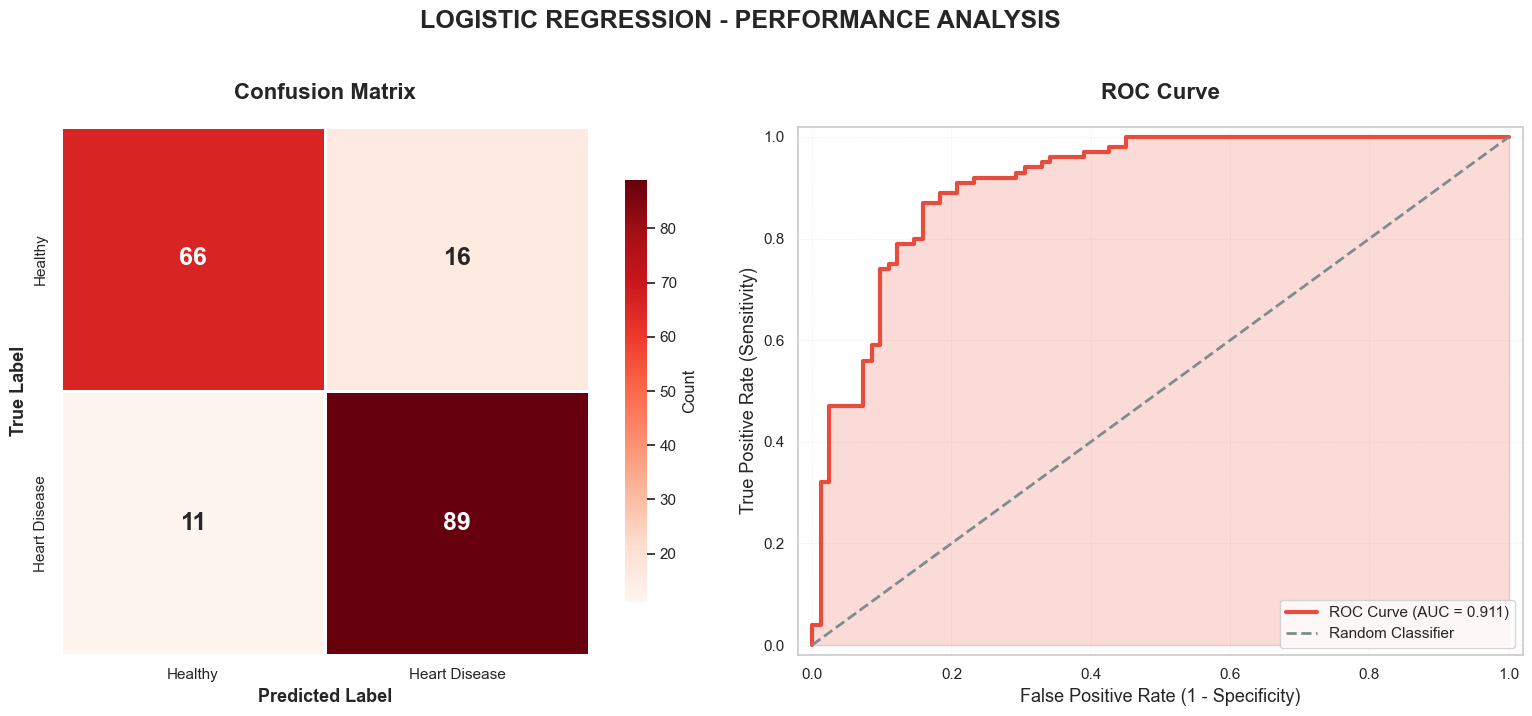

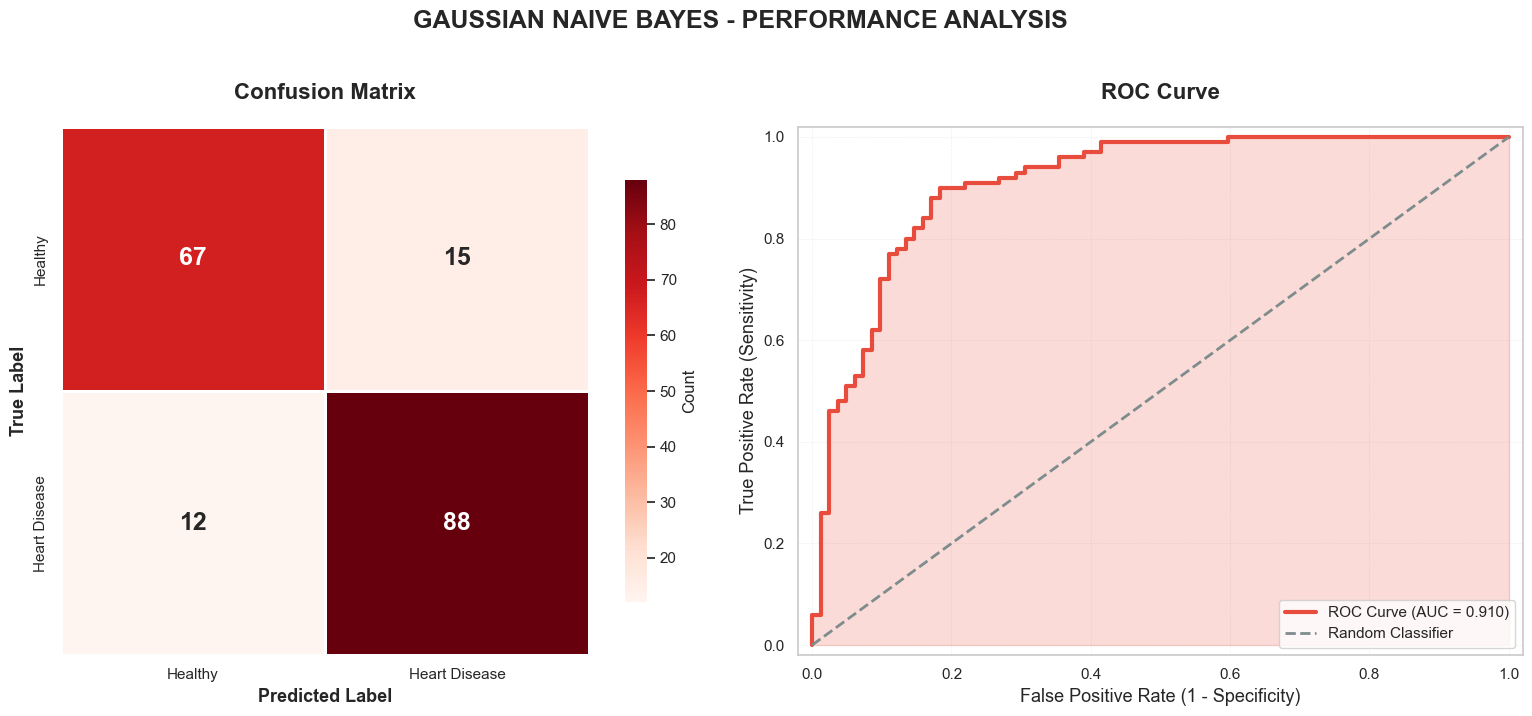

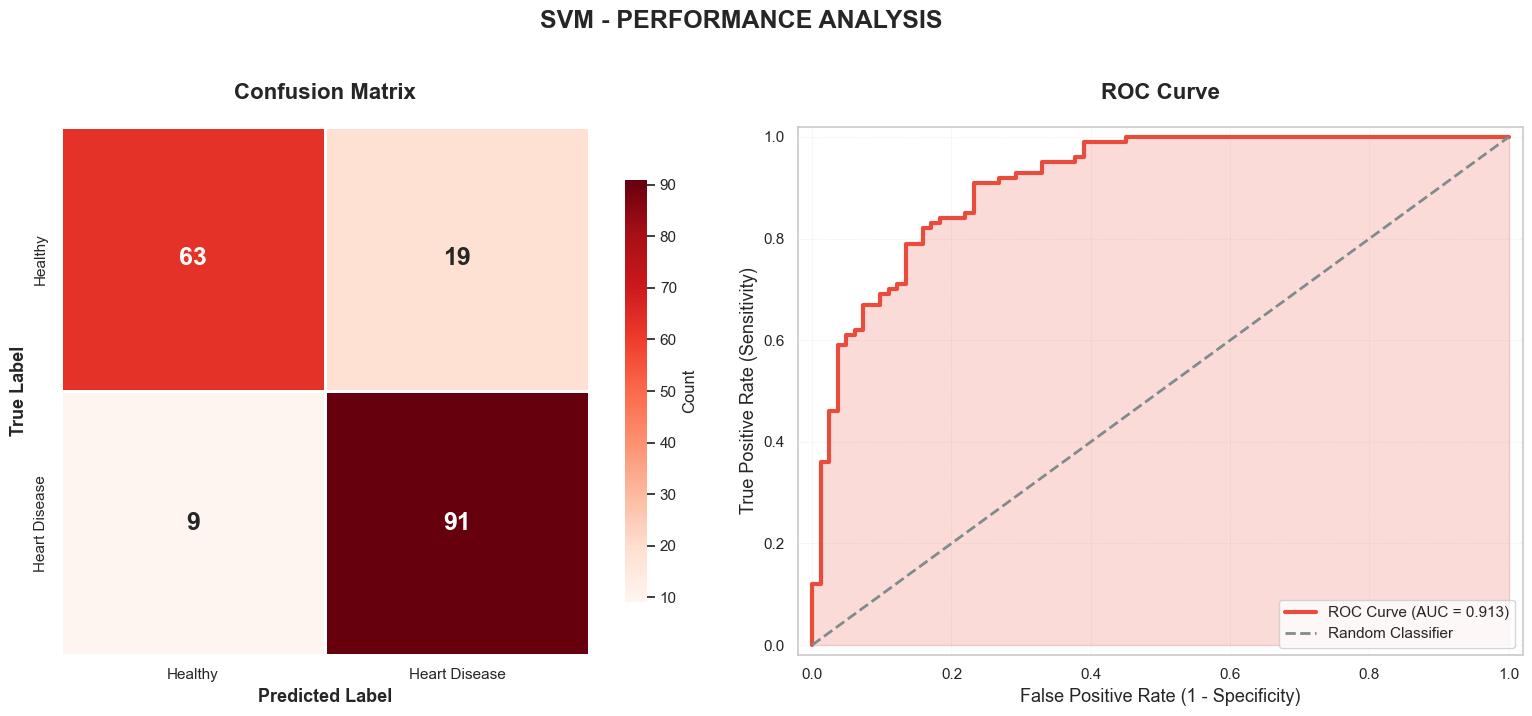

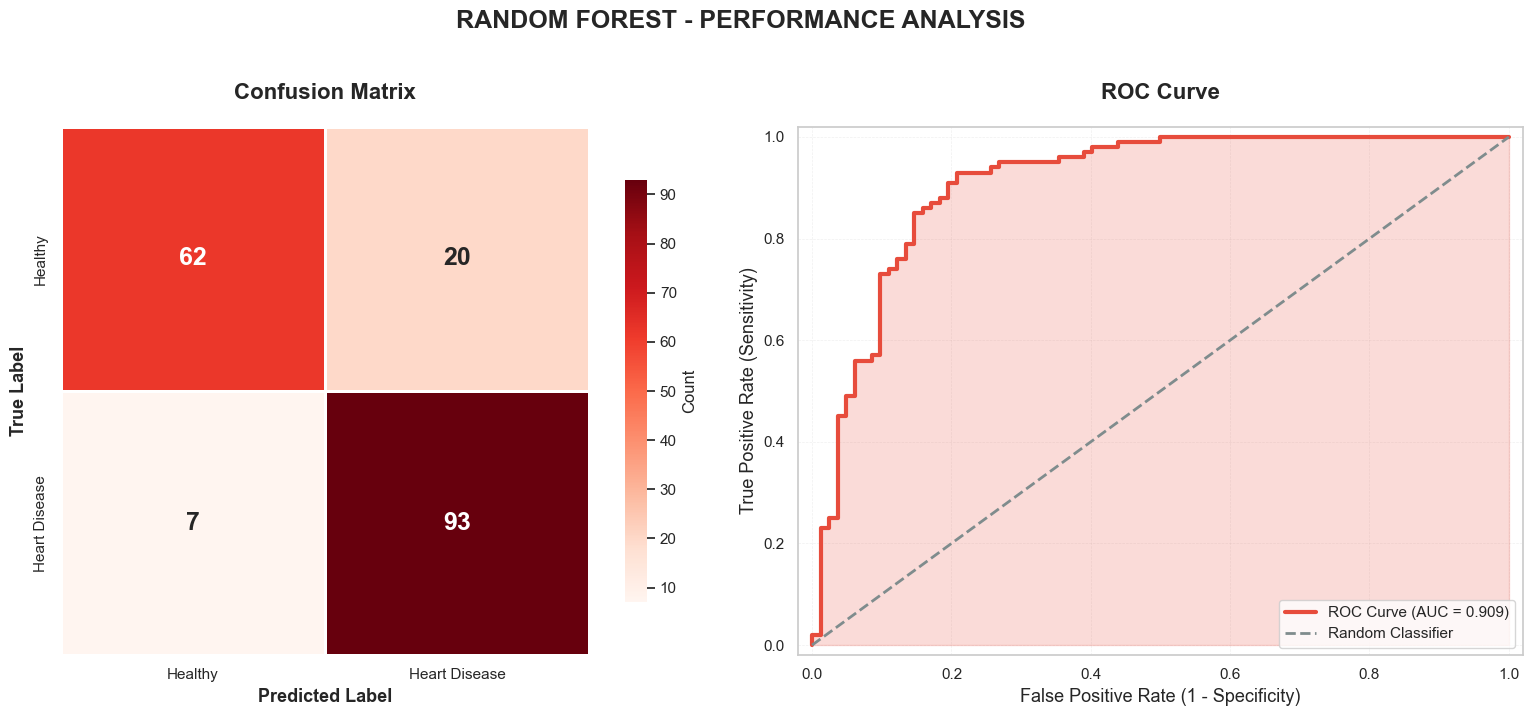

In [113]:
def evaluate_model(model, X_test, y_test, model_name, classes=['Healthy', 'Heart Disease']):
    """
    Evaluates a model, calculates metrics and produces figure with Confusion Matrix and ROC Curve.
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred) 
    macro_f1 = f1_score(y_test, y_pred, average="macro") 
    mcc = matthews_corrcoef(y_test, y_pred)

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax1,
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 18, 'weight': 'bold'},
                linewidths=2, linecolor='white', square=True)
    ax1.set_title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Predicted Label', fontsize=13, fontweight='semibold')
    ax1.set_ylabel('True Label', fontsize=13, fontweight='semibold')

    # ROC Curve
    ax2.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax2.fill_between(fpr, tpr, alpha=0.2, color='#e74c3c')
    ax2.plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--', label='Random Classifier')
    ax2.set_xlim([-0.02, 1.02]); ax2.set_ylim([-0.02, 1.02])
    ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
    ax2.set_ylabel('True Positive Rate (Sensitivity)', fontsize=13)
    ax2.set_title('ROC Curve', fontsize=16, fontweight='bold', pad=20)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.legend(loc='lower right', fontsize=11)

    fig.suptitle(f'{model_name} - PERFORMANCE ANALYSIS', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Return metrics for later use
    return {
        'accuracy': accuracy,
        'recall': recall,
        'macro_f1': macro_f1,
        'mcc': mcc,
        'roc_auc': roc_auc,
    }

# COMPLETE ANALYSIS FOR ALL MODELS
print("="*150)
results_lr = evaluate_model(lr_grid.best_estimator_, X_test_final, y_test_bin, "LOGISTIC REGRESSION")
print("="*150)

results_gnb = evaluate_model(gnb_grid.best_estimator_, X_test_final, y_test_bin, "GAUSSIAN NAIVE BAYES")
print("="*150)

results_svm = evaluate_model(svm_grid.best_estimator_, X_test_final, y_test_bin, "SVM")
print("="*150)

results_rf = evaluate_model(rf_grid.best_estimator_, X_test_final, y_test_bin, "RANDOM FOREST")
print("="*150)

**Confusion Matrix**

The confusion matrices provide a direct view of the classification outcomes and allow interpretation in clinical terms.

For all models, most predictions fall along the diagonal of the matrices, indicating a high proportion of correct classifications. However, the distribution of errors differs slightly between algorithms.

* **Random Forest** produced the lowest number of missed disease cases (7 false negatives) while also recording the highest number of false positives (20), reflecting a sensitivity-oriented classification boundary.
* **Logistic Regression** achieved a balanced error distribution with 11 false negatives and 16 false positives, resulting in stable and consistent performance.
* **Gaussian Naive Bayes** showed a similar balance with 12 false negatives and 15 false positives, performing comparably to Logistic Regression.
* **SVM** recorded 9 false negatives and 19 false positives, positioning itself between Random Forest and the other two models in terms of sensitivity.

From a clinical perspective, **false negatives are the most critical error**, as they correspond to patients with heart disease being incorrectly classified as healthy. Models that minimize this type of error are therefore preferable for diagnostic support. Under this criterion, **Random Forest** performs best, followed by **SVM**.

---

**ROC Curve Analysis**

ROC curves evaluate how well each model separates the two classes across different decision thresholds.

The AUC scores are remarkably close across all four models: **SVM (0.913)**, **Logistic Regression (0.911)**, **Gaussian Naive Bayes (0.910)**, and **Random Forest (0.909)**. This near-identical ranking indicates that all models achieve comparable overall discriminative ability.

The ROC visualizations confirm this pattern: all curves rise steeply toward the top-left region of the plot, demonstrating strong sensitivity while keeping the false positive rate relatively low. No single model dominates clearly across all thresholds.

The negligible differences in AUC suggest that the dataset contains clear and consistent patterns that all four algorithms are able to learn effectively, making the choice between them more dependent on specific clinical priorities — such as minimizing false negatives — than on raw discriminative performance.

---

In [114]:
# Collect all results in a dictionary
all_results = {
    'Logistic Regression': results_lr,
    'Gaussian Naive Bayes': results_gnb,
    'SVM': results_svm,
    'Random Forest': results_rf
}

# Results table
metrics = ['accuracy', 'recall', 'macro_f1', 'mcc', 'roc_auc']
names = {
    'accuracy': 'Accuracy',
    'recall': 'Recall', 
    'macro_f1': 'Macro F1',
    'mcc': 'MCC',
    'roc_auc': 'ROC-AUC'
}

df = pd.DataFrame({
    name: {names[metric]: results[metric] for metric in metrics}
    for name, results in all_results.items()
}).T.round(4)

print(df.sort_values(by="MCC", ascending=False))
df.to_csv('model_comparison.csv')


                      Accuracy  Recall  Macro F1     MCC  ROC-AUC
Random Forest           0.8516    0.93    0.8472  0.7036   0.9094
Logistic Regression     0.8516    0.89    0.8492  0.6998   0.9106
Gaussian Naive Bayes    0.8516    0.88    0.8496  0.6998   0.9104
SVM                     0.8462    0.91    0.8424  0.6902   0.9130


In [115]:
# Create folder for models
os.makedirs('models', exist_ok=True)

# Save all models
joblib.dump(lr_grid.best_estimator_, 'models/logistic_regression.joblib')
joblib.dump(gnb_grid.best_estimator_, 'models/naive_bayes.joblib')
joblib.dump(svm_grid.best_estimator_, 'models/svm.joblib')
joblib.dump(rf_grid.best_estimator_, 'models/random_forest.joblib')

# Save scaler and feature names (useful for future predictions)
joblib.dump(scaler, 'models/scaler.joblib')

with open('models/feature_names.txt', 'w') as f:
    for feat in X_train_final.columns:
        f.write(f"{feat}\n")
print("Feature names saved")

Feature names saved


In [116]:
# Best model for each metric
for metric in metrics:  
    column_name = names[metric]  
    best = df[column_name].idxmax()
    print(f"{names[metric]:10s}: {best} ({df.loc[best, column_name]:.4f})")

df.to_csv('best_model.csv')

Accuracy  : Logistic Regression (0.8516)
Recall    : Random Forest (0.9300)
Macro F1  : Gaussian Naive Bayes (0.8496)
MCC       : Random Forest (0.7036)
ROC-AUC   : SVM (0.9130)


**Key Observations**

Several important conclusions emerge from the evaluation:

* **Random Forest achieves the highest sensitivity (Recall = 0.93) and the strongest MCC (0.7036)**, making it the most reliable model for minimizing missed disease cases — a critical priority in clinical settings.
* **Simpler models remain highly competitive**. Logistic Regression and Gaussian Naive Bayes match Random Forest's accuracy (0.8516) and achieve marginally better Macro F1 scores (0.8492 and 0.8496 respectively), confirming that model complexity does not always translate into better overall performance.
* **SVM leads on ROC-AUC (0.9130)** but records the lowest accuracy (0.8462) and MCC (0.6902), suggesting stronger discriminative ability across thresholds but slightly weaker performance at the chosen decision boundary.
* **All four models achieve identical accuracy (0.8516, except SVM)**, with differences concentrated in sensitivity-specificity trade-offs rather than in overall correctness.

---

**Final Considerations**

Overall, the evaluation results indicate that **all four models perform well on the dataset**, with only marginal differences across metrics. The AUC scores range narrowly between 0.909 and 0.913, confirming that all algorithms successfully capture the underlying patterns in the data.

However, when prioritizing **clinical utility**, Random Forest stands out as the most appropriate choice: it achieves the highest recall and MCC, meaning it is the most effective at correctly identifying patients with heart disease while maintaining a reliable overall prediction quality.

For this reason, **Random Forest was selected as the final model**, offering the best compromise between diagnostic sensitivity, predictive accuracy, and robustness across evaluation metrics.